In [ ]:
import pickle

# Load the pickle file
with open('../network_data.pkl', 'rb') as f:
    data = pickle.load(f)

In [ ]:
print(data)

In [ ]:
def convert_data_to_sankey(data):
    sankey_nodes = set()
    sankey_links = {}

    for bip in data.get('nodes', []):
        # Extract values with fallbacks
        layer_raw = bip.get('group') or bip.get('raw', {}).get('preamble', {}).get('layer') or "Unknown Layer"
        status_raw = bip.get('status') or bip.get('raw', {}).get('preamble', {}).get('status') or "Unknown Status"
        type_raw = bip.get('type') or bip.get('raw', {}).get('preamble', {}).get('type') or "Unknown Type"

        # Clean strings
        layer = str(layer_raw).strip() or "Unknown Layer"
        status = str(status_raw).strip() or "Unknown Status"
        type_ = str(type_raw).strip() or "Unknown Type"

        # Skip unknowns
        if "Unknown" in layer or "Unknown" in status or "Unknown" in type_:
            continue

        # Add node names
        sankey_nodes.update([layer, status, type_])

        # Track link counts
        link1 = f"{layer}--{status}"
        link2 = f"{status}--{type_}"
        sankey_links[link1] = sankey_links.get(link1, 0) + 1
        sankey_links[link2] = sankey_links.get(link2, 0) + 1

    # Map node names to numeric IDs
    node_list = list(sankey_nodes)
    node_id_map = {label: i for i, label in enumerate(node_list)}

    # Build sankey-compatible dict
    sankey_data = {
        "nodes": [{"id": node_id_map[label], "name": label} for label in node_list],
        "links": []
    }

    for key, value in sankey_links.items():
        source_label, target_label = key.split("--")
        sankey_data["links"].append({
            "source": node_id_map[source_label],
            "target": node_id_map[target_label],
            "value": value
        })

    return sankey_data


In [ ]:
sankey_data = convert_data_to_sankey(data)

In [5]:
import plotly.graph_objects as go
from collections import defaultdict

def draw_sankey_chart(data, title="BIP Sankey Diagram", save_as=None):
    nodes = data["nodes"]
    links = data["links"]

    # --- 1) Compute totals per node (use true counts if available) ----------
    node_totals = defaultdict(int)

    for link in links:
        src = link["source"]
        tgt = link["target"]
        c = link.get("count", link["value"])  # prefer real count over scaled value

        # If you want "total flow touching the node" (in + out), keep both:
        node_totals[src] += c
        node_totals[tgt] += c

    # --- 2) Build labels with totals ----------------------------------------
    labels_with_totals = [
    f"{node['name']} (n = {node_totals[i]})"
    for i, node in enumerate(nodes)
]

    # --- 3) Build Sankey -----------------------------------------------------
    sankey_nodes = dict(
        label=labels_with_totals,
        pad=28,
        thickness=18,
        line=dict(color="black", width=0.5),
    )

    sankey_links = dict(
        source=[link["source"] for link in links],
        target=[link["target"] for link in links],
        value=[link["value"] for link in links],  # visual thickness (your scaled values)
    )

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=sankey_nodes,
        link=sankey_links
    ))

    fig.update_layout(
        title_text=title,
        font_size=12,
        width=1200,
        height=650,
        margin=dict(l=40, r=40, t=70, b=40),
        font=dict(size=12, color="black", shadow="none")
    )

    # --- 4) Save (with explicit sizing) -------------------------------------
    if save_as:
        fig.write_image(save_as, width=1200, height=650, scale=2)
        print(f"Saved Sankey diagram to {save_as}")

    fig.show()


# Usage:
# grouped_sankey_data = convert_data_to_sankey_grouped_status(data)
# draw_sankey_chart(grouped_sankey_data, save_as="sankey_bip.pdf")


In [ ]:
draw_sankey_chart(sankey_data, title="BIPs by Layer → Status → Type")

In [7]:
def convert_data_to_sankey_grouped_status(data):
    import math

    # --- 1. Lookup tables ----------------------------------------------------
    status_group_map = {
        "Draft": "In Progress",
        "Review": "In Progress",
        "Proposed": "In Progress",
        "Obsolete": "Inactive",
        "Final": "Completed",
        "Active": "Completed",
        "Rejected": "Inactive",
        "Withdrawn": "Inactive",
        "Deferred": "Inactive",
        "Replaced": "Inactive"
    }

    type_clean_map = {
        "Standard": "Standards Track",
        "Standards": "Standards Track",
        "Standard Track": "Standards Track",
        "Standards-Track": "Standards Track",
    }

    # Fixed order for columns
    ordered_layers = [
        "Consensus", "Applications", "Application", "Network", "Wallet", "Other"
    ]
    ordered_status = ["In Progress", "Completed", "Inactive"]
    ordered_types = ["Standards Track", "Informational", "Process"]

    # --- 2. Storage ----------------------------------------------------------
    sankey_nodes = set()
    sankey_links = {}

    # --- 3. Extract + clean data --------------------------------------------
    for bip in data.get('nodes', []):

        layer_raw = (
            bip.get('group')
            or bip.get('raw', {}).get('preamble', {}).get('layer')
            or "Unknown Layer"
        )
        status_raw = (
            bip.get('status')
            or bip.get('raw', {}).get('preamble', {}).get('status')
            or "Unknown Status"
        )
        type_raw = (
            bip.get('type')
            or bip.get('raw', {}).get('preamble', {}).get('type')
            or "Unknown Type"
        )

        # --- CLEANING FIX STARTS HERE ---
        layer = str(layer_raw).strip() or "Unknown Layer"

        # Clean raw status string
        status_raw_clean = str(status_raw).strip() or "Unknown Status"

        # Extract base status before parentheses
        status_base = status_raw_clean.split("(")[0].strip()

        # Apply grouping
        status = status_group_map.get(status_base, status_base)

        type_ = str(type_raw).strip() or "Unknown Type"
        # --- CLEANING FIX ENDS HERE ---

        # unify types
        type_ = type_clean_map.get(type_, type_)

        # replace true unknowns with grouped labels
        if "Unknown" in layer:
            layer = "Other"
        if "Unknown" in status:
            status = "Unknown Status"
        if "Unknown" in type_:
            type_ = "Unknown Type"

        sankey_nodes.update([layer, status, type_])

        # layer → status
        link1 = f"{layer}--{status}"
        sankey_links[link1] = sankey_links.get(link1, 0) + 1

        # status → type
        link2 = f"{status}--{type_}"
        sankey_links[link2] = sankey_links.get(link2, 0) + 1

    # --- 4. Construct node list with fixed ordering --------------------------
    node_list = (
        [n for n in ordered_layers if n in sankey_nodes] +
        [n for n in ordered_status if n in sankey_nodes] +
        [n for n in ordered_types if n in sankey_nodes] +
        [n for n in sankey_nodes
         if n not in (ordered_layers + ordered_status + ordered_types)]
    )

    node_id_map = {label: i for i, label in enumerate(node_list)}

    # --- 5. Scale link values (log) ------------------------------------------
    maxval = max(sankey_links.values()) if sankey_links else 1
    scaled_links = {
        k: max(1, math.log(v + 1) * 3)
        for k, v in sankey_links.items()
    }

    # --- 6. Build JSON structure ---------------------------------------------
    sankey_data = {
        "nodes": [],
        "links": []
    }

    for label in node_list:
        node = {"id": node_id_map[label], "name": label}

        # assign left → middle → right
        if label in ordered_layers:
            node["layer"] = 0
        elif label in ordered_status:
            node["layer"] = 1
        else:
            node["layer"] = 2

        sankey_data["nodes"].append(node)

    for key, value in scaled_links.items():
        source_label, target_label = key.split("--")
        sankey_data["links"].append({
            "source": node_id_map[source_label],
            "target": node_id_map[target_label],
            "value": value,
            "count": sankey_links[key]
        })

    return sankey_data


Saved Sankey diagram to sankey_bip.pdf


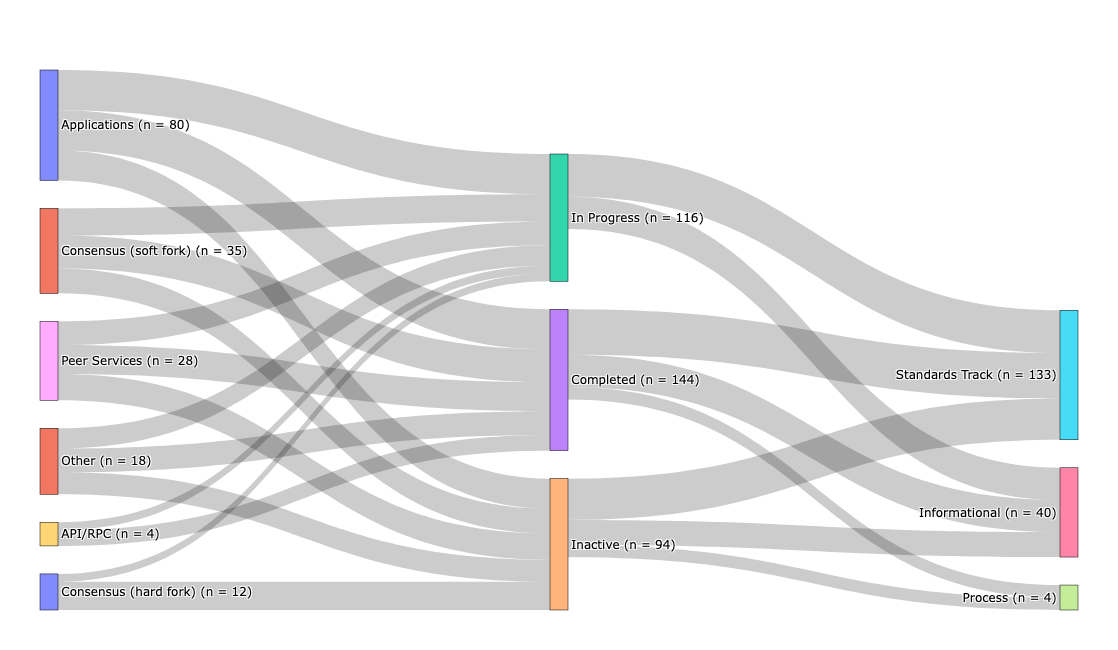

In [8]:
grouped_sankey_data = convert_data_to_sankey_grouped_status(data)
draw_sankey_chart(grouped_sankey_data,title="", save_as="sankey_bip.pdf")

In [9]:
#ugly Draft status must be cleaned

In [10]:
import pandas as pd

def convert_data_to_sankey_table(data):
    sankey_links = {}

    for bip in data.get('nodes', []):
        # Extract values with fallbacks
        layer_raw = bip.get('group') or bip.get('raw', {}).get('preamble', {}).get('layer') or "Unknown Layer"
        status_raw = bip.get('status') or bip.get('raw', {}).get('preamble', {}).get('status') or "Unknown Status"
        type_raw = bip.get('type') or bip.get('raw', {}).get('preamble', {}).get('type') or "Unknown Type"

        # Clean strings
        layer = str(layer_raw).strip() or "Unknown Layer"
        status = str(status_raw).strip() or "Unknown Status"
        type_ = str(type_raw).strip() or "Unknown Type"

        # Skip unknowns
        if "Unknown" in layer or "Unknown" in status or "Unknown" in type_:
            continue

        # Track link counts
        link1 = (layer, status)
        link2 = (status, type_)
        sankey_links[link1] = sankey_links.get(link1, 0) + 1
        sankey_links[link2] = sankey_links.get(link2, 0) + 1

    # Convert to DataFrame
    df = pd.DataFrame([
        {"Source": source, "Target": target, "Count": count}
        for (source, target), count in sankey_links.items()
    ])

    return df


In [11]:
table_df = convert_data_to_sankey_table(data)
table_df.sort_values(by="Count", ascending=False, inplace=True)
table_df.reset_index(drop=True, inplace=True)
display(table_df)  # If you're in a notebook




,Source,Target,Count
0,Final,Standards Track,53
1,Applications,Final,33
2,Draft,Standards Track,29
3,Applications,Draft,21
4,Rejected,Standards Track,20
5,Consensus (soft fork),Final,17
6,Applications,Proposed,12
7,Peer Services,Final,12
8,Final,Informational,12
9,Withdrawn,Standards Track,12


In [12]:
from collections import defaultdict, Counter
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

# Create a nested dict: {group: Counter({status: count})}
group_status_counts = defaultdict(Counter)

for node in data['nodes']:
    group = node.get('group') or 'Unknown'  # This ensures no None
    status = node.get('status', 'Unknown').capitalize()
    group_status_counts[group][status] += 1



In [13]:
# Extract unique groups and statuses
groups = sorted(group_status_counts.keys())
statuses = sorted(set(status for counts in group_status_counts.values() for status in counts))

# Build matrix: one list per status, showing its count in each group
status_matrix = {status: [] for status in statuses}
for group in groups:
    for status in statuses:
        count = group_status_counts[group].get(status, 0)
        status_matrix[status].append(count)


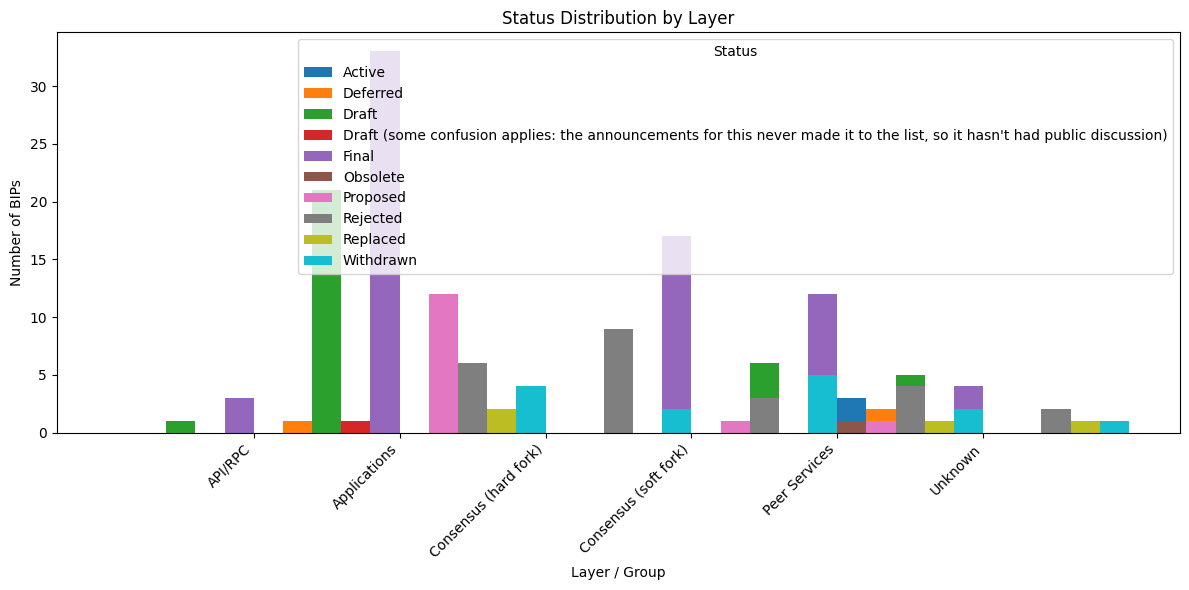

In [14]:
bar_width = 0.2
x = np.arange(len(groups))  # positions for groups

plt.figure(figsize=(12, 6))

for i, status in enumerate(statuses):
    offset = (i - len(statuses)/2) * bar_width + bar_width/2
    plt.bar(x + offset, status_matrix[status], width=bar_width, label=status)

plt.xticks(x, groups, rotation=45, ha='right')
plt.xlabel("Layer / Group")
plt.ylabel("Number of BIPs")
plt.title("Status Distribution by Layer")
plt.legend(title="Status")
plt.tight_layout()
plt.show()


In [15]:
from collections import defaultdict, Counter
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Count BIPs by status per year
status_by_year = defaultdict(Counter)

for node in data['nodes']:
    created = node.get('created')
    status = node.get('status', 'Unknown').capitalize()

    if created:
        try:
            year = datetime.strptime(created, "%Y-%m-%d").year
            status_by_year[year][status] += 1
        except ValueError:
            continue


In [16]:
# Define the statuses you're interested in
statuses = ['Draft', 'Final', 'Rejected']
years = sorted(status_by_year.keys())

# Create a list of values for each status across years
status_counts = {status: [] for status in statuses}
for year in years:
    for status in statuses:
        status_counts[status].append(status_by_year[year].get(status, 0))

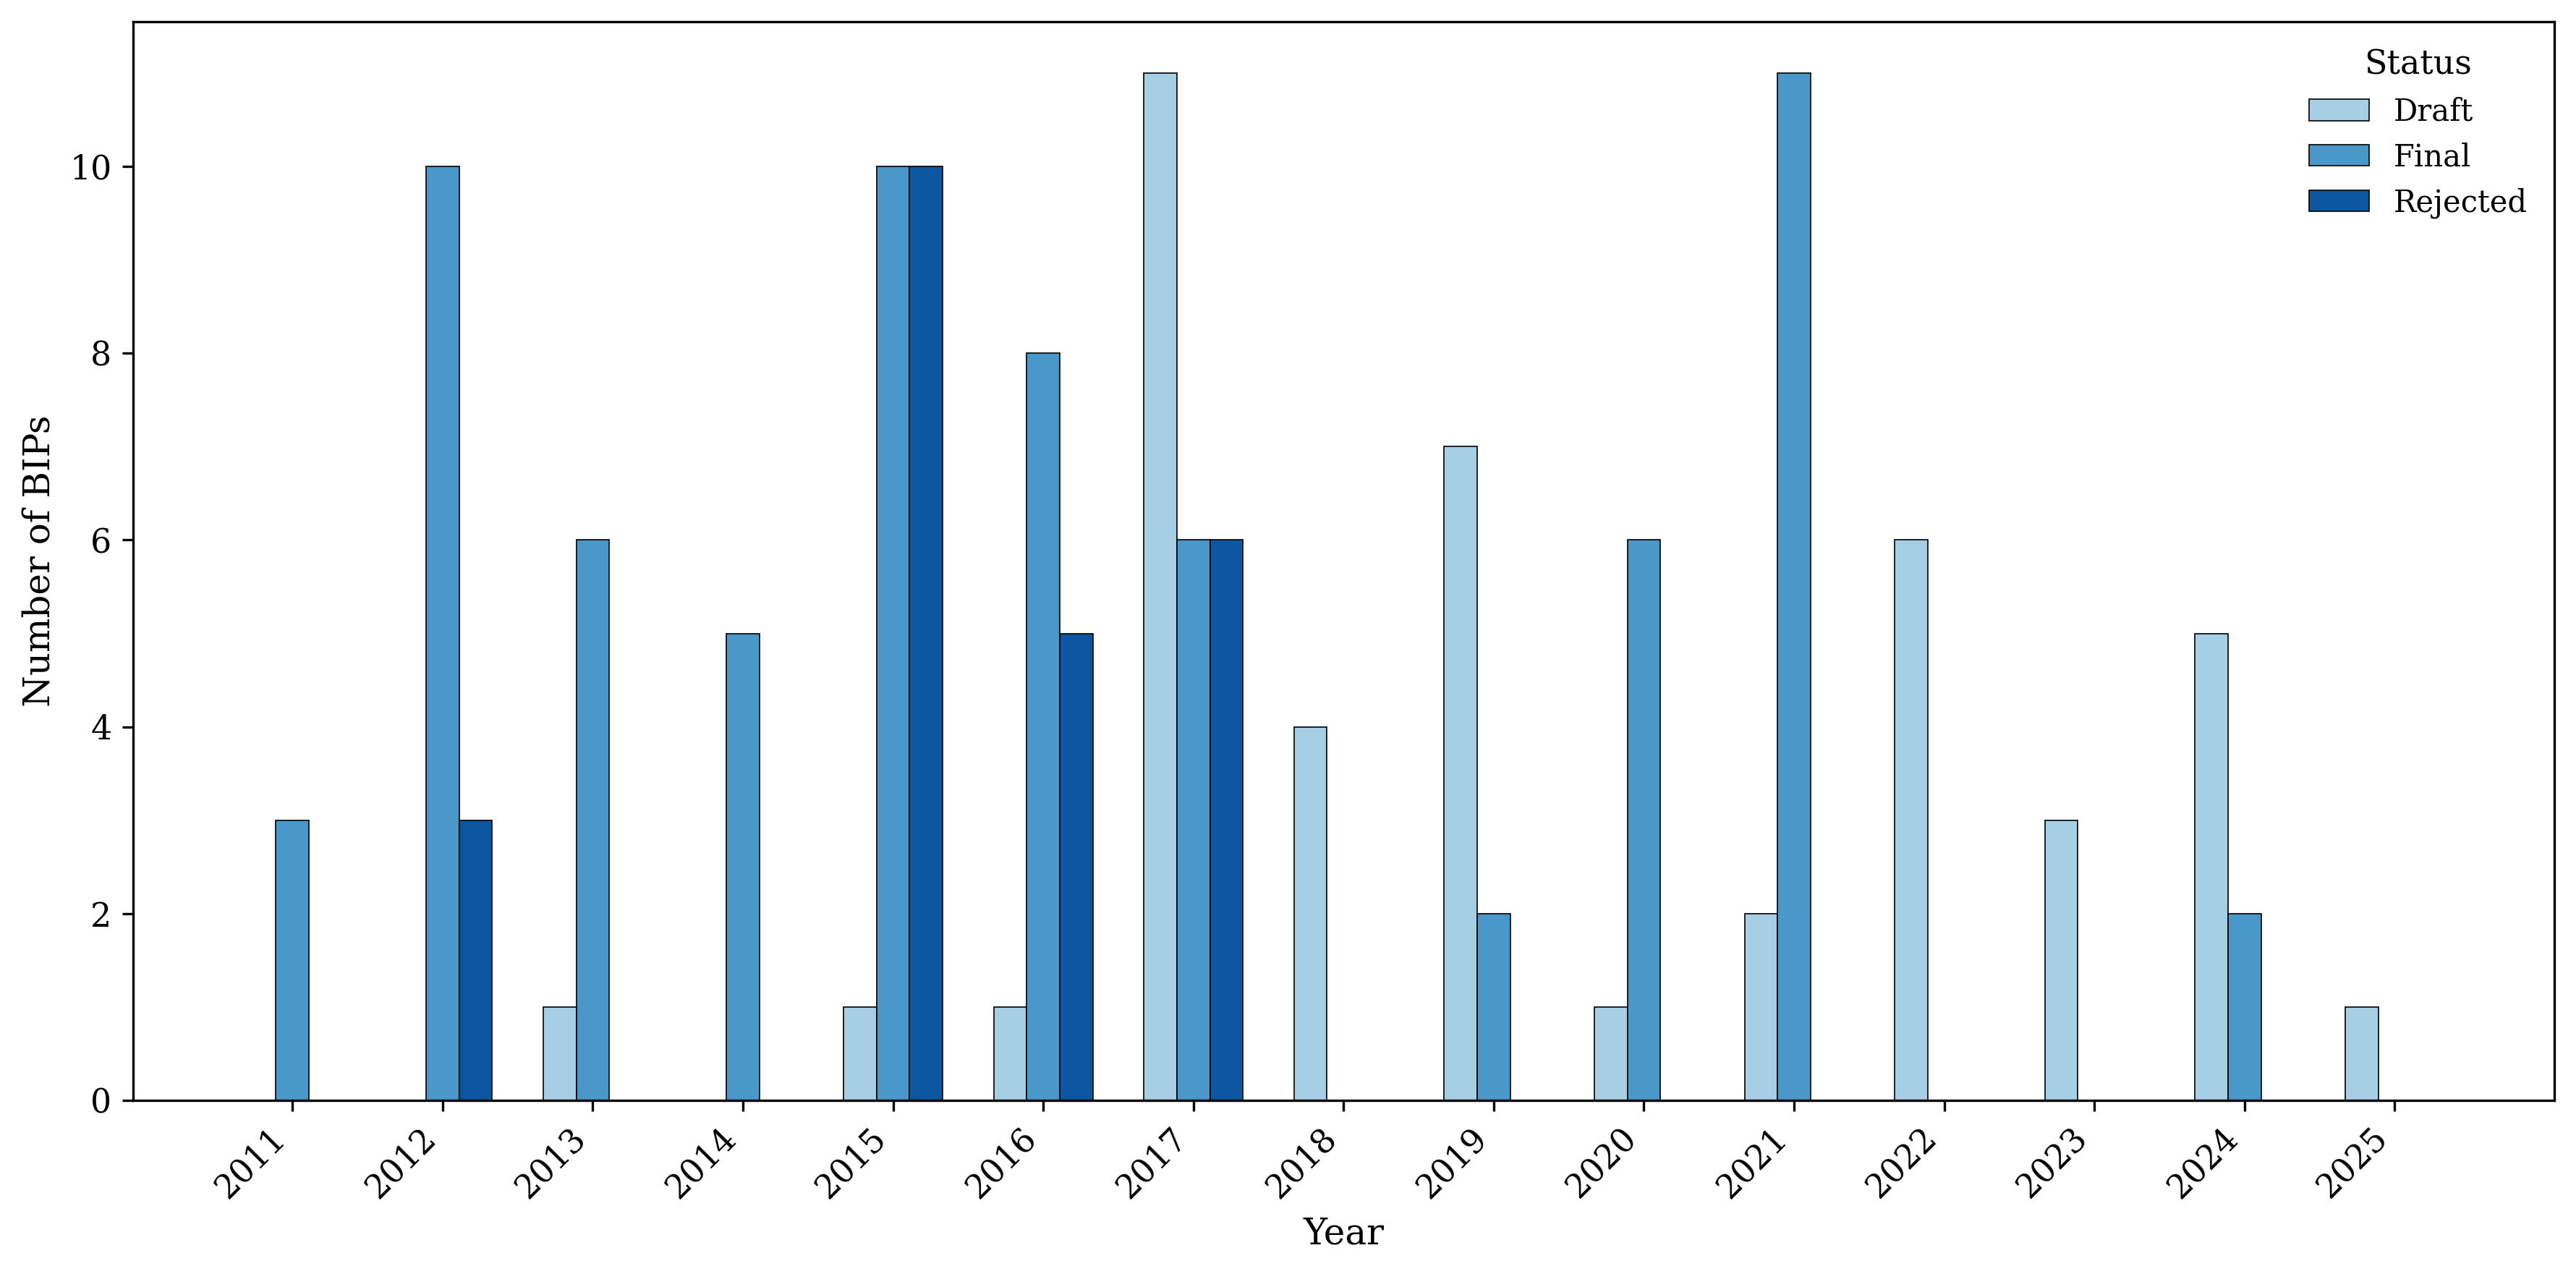

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Thesis-quality figure settings ---
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "figure.dpi": 300,
})

# --- Bar chart settings ---
bar_width = 0.22
x = np.arange(len(years))

plt.figure(figsize=(12, 6))

colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(statuses)))

for i, status in enumerate(statuses):
    offset = (i - (len(statuses)-1)/2) * bar_width
    plt.bar(
        x + offset,
        status_counts[status],
        width=bar_width,
        label=status,
        color=colors[i],
        edgecolor="black",
        linewidth=0.4
    )


plt.xticks(x, years, rotation=45, ha="right")
plt.xlabel("Year")
plt.ylabel("Number of BIPs")
plt.legend(title="Status", frameon=False)

plt.tight_layout()

# --- Save BEFORE showing ---
plt.savefig("bip_status_over_time.pdf", format="pdf", bbox_inches="tight")
plt.show()
